# Custom Grid Completion Analysis

This notebook analyzes completion rates and coverage for benchmark runs. Works with both rent scenario grids and custom grids (like Dear Abby).

## Features
- Grid type detection (rent scenario vs custom grids)
- Coverage analysis (which models answered which prompts)
- Completion statistics by model and prompt
- Missing combinations analysis
- Interactive visualizations


In [23]:
# Standard library imports
from __future__ import annotations
from pathlib import Path
from datetime import datetime
import json
import itertools
import sys
import warnings

# Third-party imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Project imports
# Add project root to path to import RunRecord
# Notebook is in outputs/runs/, so go up 2 levels to project root
project_root = Path().resolve()
if project_root.name == 'runs':
    project_root = project_root.parent.parent
elif project_root.name == 'outputs':
    project_root = project_root.parent
sys.path.insert(0, str(project_root))
from src.benchmark.core.types import RunRecord

# Configure warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100


## Configuration

Enter the run hash ID below to analyze a specific benchmark run.


In [24]:
# Hash ID Input
RUN_HASH = "f2d3e4b22e01564f"  # Change this to analyze a different run

# Define paths - try relative to current directory first, then project root
# If notebook is in outputs/runs/, run_dir should be in same directory
run_dir = Path(f"run_{RUN_HASH}")
if not run_dir.exists():
    # Try from project root
    run_dir = Path(f"outputs/runs/run_{RUN_HASH}").resolve()
    if not run_dir.exists():
        # Try absolute path from project root (where project_root was determined)
        run_dir = project_root / "outputs" / "runs" / f"run_{RUN_HASH}"

run_jsonl = run_dir / "run.jsonl"
grid_jsonl = run_dir / "grid.jsonl"

# Validate paths exist
if not run_dir.exists():
    raise FileNotFoundError(f"Run directory not found: {run_dir}")
if not run_jsonl.exists():
    raise FileNotFoundError(f"Run data file not found: {run_jsonl}")
if not grid_jsonl.exists():
    raise FileNotFoundError(f"Grid data file not found: {grid_jsonl}")

# Print relative paths for cleaner output
run_dir_rel = run_dir.relative_to(project_root) if run_dir.is_relative_to(project_root) else run_dir
run_jsonl_rel = run_jsonl.relative_to(project_root) if run_jsonl.is_relative_to(project_root) else run_jsonl
grid_jsonl_rel = grid_jsonl.relative_to(project_root) if grid_jsonl.is_relative_to(project_root) else grid_jsonl
print(f"Run directory: {run_dir_rel}")
print(f"Run data file: {run_jsonl_rel}")
print(f"Grid data file: {grid_jsonl_rel}")


Run directory: run_f2d3e4b22e01564f
Run data file: run_f2d3e4b22e01564f/run.jsonl
Grid data file: run_f2d3e4b22e01564f/grid.jsonl


## Data Loading


In [25]:
# Load Data
def load_run_data(path: Path) -> pd.DataFrame:
    """Load run data from JSONL file using RunRecord."""
    records = []
    for record in RunRecord.iter_jsonl(path):
        if record.is_success():
            # Convert RunRecord to dict
            payload = record.to_payload()
            records.append(payload)
    return pd.DataFrame(records)

def load_grid_data(path: Path) -> pd.DataFrame:
    """Load grid data from JSONL file."""
    records = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError:
                continue
    return pd.DataFrame(records)

# Load data
df_runs = load_run_data(run_jsonl)
df_grid = load_grid_data(grid_jsonl)

print(f"✓ Loaded {len(df_runs)} successful run records")
print(f"✓ Loaded {len(df_grid)} grid prompts")
print(f"\nRun data shape: {df_runs.shape}")
print(f"Grid data shape: {df_grid.shape}")
print(f"\nUnique models: {df_runs['model_id'].nunique()}")
print(f"Unique prompts: {df_runs['prompt_id'].nunique()}")


✓ Loaded 2225 successful run records
✓ Loaded 150 grid prompts

Run data shape: (2225, 18)
Grid data shape: (150, 3)

Unique models: 28
Unique prompts: 150


## Grid Type Detection


In [26]:
# Detect grid type and extract available metadata
is_custom_grid = False
available_factor_fields = set()

if len(df_grid) > 0:
    first_record = df_grid.iloc[0]
    # Check if it's a custom grid (has messages field)
    if 'messages' in first_record and first_record['messages'] is not None:
        is_custom_grid = True
    
    # Extract all available factor fields from grid
    for _, row in df_grid.iterrows():
        factors = row.get('factors', {}) or {}
        if isinstance(factors, dict):
            available_factor_fields.update(factors.keys())

grid_type = "custom grid" if is_custom_grid else "rent scenario grid"
print(f"Grid type: {grid_type}")
print(f"Available factor fields: {sorted(available_factor_fields)}")

# Extract factor columns from run data dynamically
def extract_factors(row):
    """Extract factor values from factors dict."""
    factors = row.get('factors', {}) or {}
    if not isinstance(factors, dict):
        factors = {}
    # Return all available fields as a Series
    return pd.Series(factors)

# Apply extraction - get all factor columns
factor_cols = df_runs.apply(extract_factors, axis=1, result_type='expand')

# Only add columns that don't already exist in df_runs
for col in factor_cols.columns:
    if col not in df_runs.columns:
        df_runs[col] = factor_cols[col]
    else:
        # If column exists but has NaN values, fill from factors
        mask = df_runs[col].isna()
        df_runs.loc[mask, col] = factor_cols.loc[mask, col]

print(f"\n✓ Extracted factor columns: {sorted([c for c in factor_cols.columns if c in df_runs.columns])}")

# Filter to successful records only
df_success = df_runs.copy()
print(f"\n✓ Using {len(df_success)} successful records for analysis")


Grid type: custom grid
Available factor fields: ['date', 'letterId', 'question_id', 'title', 'year']

✓ Extracted factor columns: ['date', 'letterId', 'question_id', 'title', 'year']

✓ Using 2225 successful records for analysis


## Coverage Matrix Creation


In [27]:
# Create model-prompt coverage matrix
coverage = df_success.groupby(['model_id', 'prompt_id']).size().unstack(fill_value=0)

# Get all expected models and prompts
all_models = set(df_success['model_id'].unique())
all_prompts = set(df_grid['prompt_id'].unique())
total_expected = len(all_models) * len(all_prompts)
total_actual = coverage.sum().sum()
total_missing = total_expected - total_actual

print(f"✓ Coverage matrix shape: {coverage.shape}")
print(f"Total expected combinations: {total_expected} (models: {len(all_models)}, prompts: {len(all_prompts)})")
print(f"Total actual combinations: {total_actual}")
print(f"Total missing combinations: {total_missing}")
print(f"Overall completion rate: {(total_actual / total_expected * 100):.1f}%")


✓ Coverage matrix shape: (28, 150)
Total expected combinations: 4200 (models: 28, prompts: 150)
Total actual combinations: 2225
Total missing combinations: 1975
Overall completion rate: 53.0%


## Completion Statistics


In [28]:
# Completion rate per model
completion_by_model = df_success.groupby('model_id')['prompt_id'].nunique().reset_index()
completion_by_model.columns = ['model_id', 'prompts_answered']
completion_by_model['completion_rate'] = (completion_by_model['prompts_answered'] / len(all_prompts)) * 100
completion_by_model = completion_by_model.sort_values('completion_rate', ascending=False)

# Completion rate per prompt
completion_by_prompt = df_success.groupby('prompt_id')['model_id'].nunique().reset_index()
completion_by_prompt.columns = ['prompt_id', 'models_answered']
completion_by_prompt['completion_rate'] = (completion_by_prompt['models_answered'] / len(all_models)) * 100
completion_by_prompt = completion_by_prompt.sort_values('prompt_id')

# Print summary
overall_completion = (total_actual / total_expected) * 100
print("Coverage Summary:")
print(f"  Total models: {len(all_models)}")
print(f"  Total prompts: {len(all_prompts)}")
print(f"  Overall completion rate (%): {overall_completion:.1f}%")
print(f"\nCompletion Rate by Model:")
print(completion_by_model.to_string(index=False))
print(f"\nCompletion Rate by Prompt (first 20):")
print(completion_by_prompt.head(20).to_string(index=False))
if len(completion_by_prompt) > 20:
    print(f"\n... and {len(completion_by_prompt) - 20} more prompts")


Coverage Summary:
  Total models: 28
  Total prompts: 150
  Overall completion rate (%): 53.0%

Completion Rate by Model:
                                                model_id  prompts_answered  completion_rate
                                 google/gemini-2.0-flash               150       100.000000
                            google/gemini-2.0-flash-lite               150       100.000000
                            mistral/mistral-small-latest               150       100.000000
                               groq/llama-3.1-8b-instant               150       100.000000
      groq/meta-llama/llama-4-maverick-17b-128e-instruct               150       100.000000
                        groq/moonshotai/kimi-k2-instruct               150       100.000000
                 cerebras/qwen-3-235b-a22b-instruct-2507               150       100.000000
                            google/gemini-2.5-flash-lite               146        97.333333
          groq/meta-llama/llama-4-scout-17b-16e-in

## Coverage Heatmap Visualization


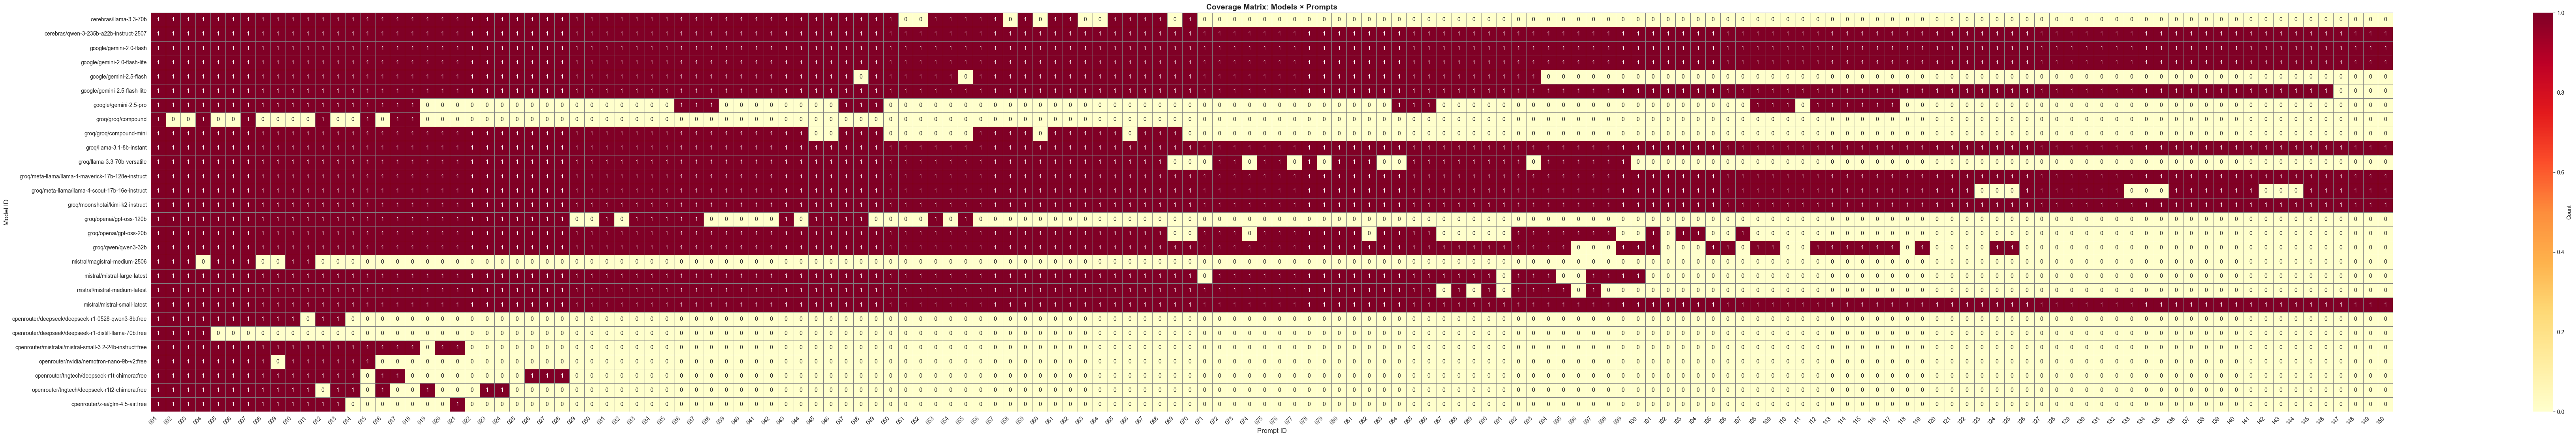

Coverage matrix: 28 models × 150 prompts
Total combinations: 2225
Missing combinations: 1975


In [29]:
# Coverage Heatmap

# Sort coverage matrix for better visualization
coverage_sorted = coverage.sort_index(axis=0).sort_index(axis=1)

plt.figure(figsize=(max(12, len(coverage_sorted.columns) * 0.5), max(6, len(coverage_sorted.index) * 0.4)))
sns.heatmap(
    coverage_sorted,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    cbar_kws={'label': 'Count'},
    linewidths=0.5,
    linecolor='gray'
)
plt.title("Coverage Matrix: Models × Prompts", fontsize=14, fontweight='bold')
plt.xlabel("Prompt ID", fontsize=12)
plt.ylabel("Model ID", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"Coverage matrix: {coverage_sorted.shape[0]} models × {coverage_sorted.shape[1]} prompts")
print(f"Total combinations: {coverage_sorted.sum().sum()}")
print(f"Missing combinations: {(coverage_sorted == 0).sum().sum()}")


## Completion Rate by Model


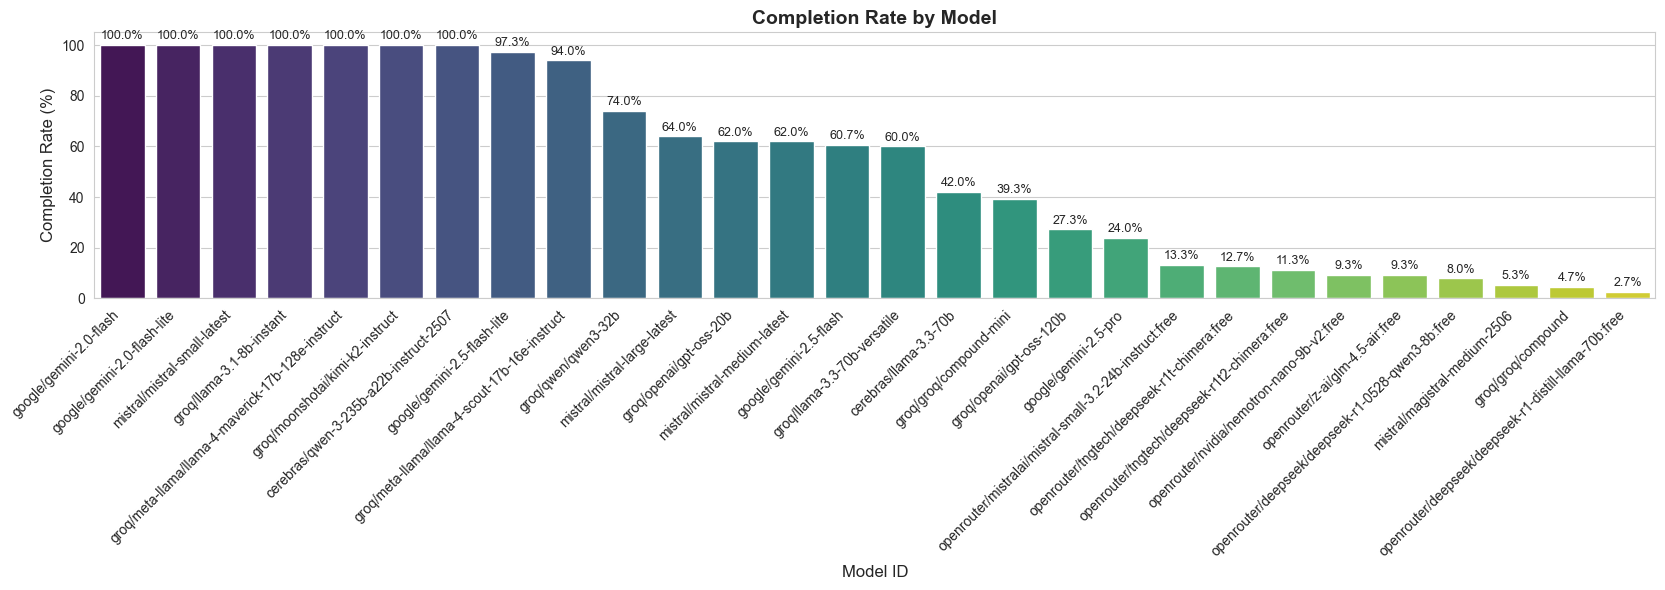

In [30]:
# Completion Rates by Model

plt.figure(figsize=(max(12, len(completion_by_model) * 0.6), 6))
ax = sns.barplot(
    data=completion_by_model,
    x='model_id',
    y='completion_rate',
    palette='viridis'
)
plt.title("Completion Rate by Model", fontsize=14, fontweight='bold')
plt.xlabel("Model ID", fontsize=12)
plt.ylabel("Completion Rate (%)", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 105)

# Add percentage labels on bars
for i, (idx, row) in enumerate(completion_by_model.iterrows()):
    ax.text(i, row['completion_rate'] + 1, f"{row['completion_rate']:.1f}%",
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


## Completion Rate by Prompt


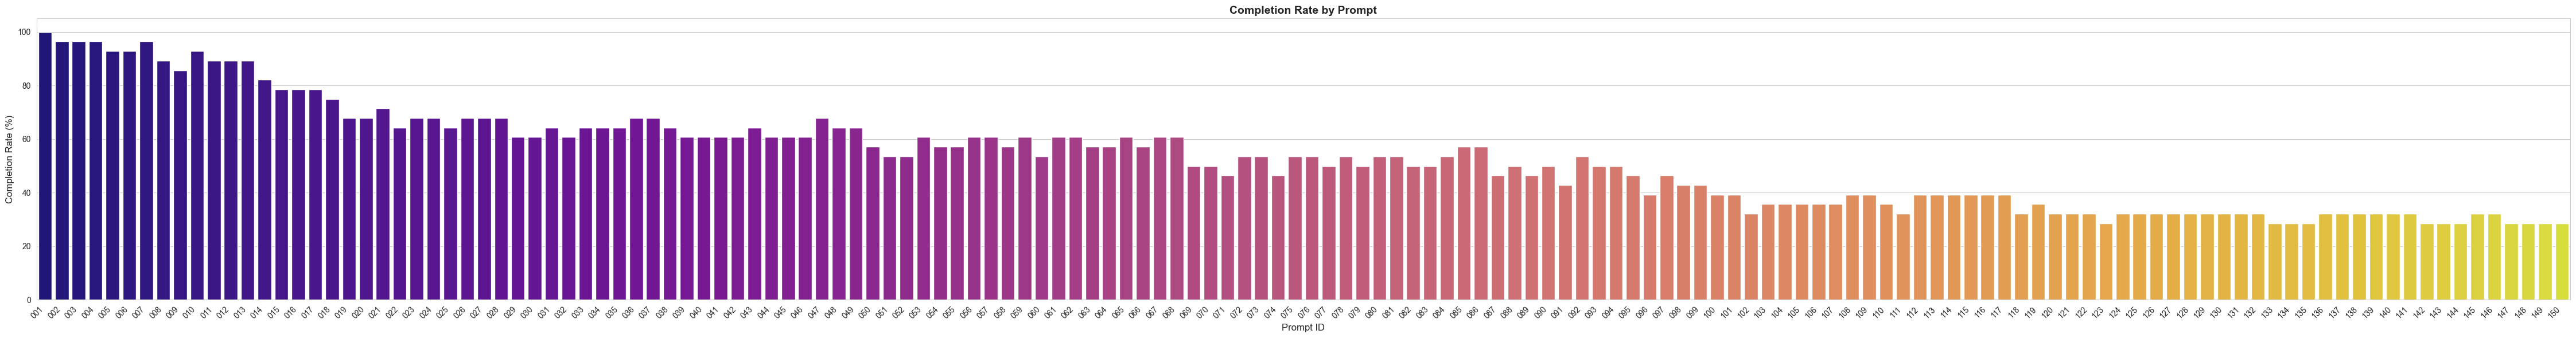

In [31]:
# Completion Rates by Prompt

plt.figure(figsize=(max(12, len(completion_by_prompt) * 0.3), 6))
ax = sns.barplot(
    data=completion_by_prompt,
    x='prompt_id',
    y='completion_rate',
    palette='plasma'
)
plt.title("Completion Rate by Prompt", fontsize=14, fontweight='bold')
plt.xlabel("Prompt ID", fontsize=12)
plt.ylabel("Completion Rate (%)", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 105)

# Add percentage labels on bars (only if not too many prompts)
if len(completion_by_prompt) <= 50:
    for i, (idx, row) in enumerate(completion_by_prompt.iterrows()):
        ax.text(i, row['completion_rate'] + 1, f"{row['completion_rate']:.1f}%",
                ha='center', va='bottom', fontsize=8, rotation=90)

plt.tight_layout()
plt.show()


## Missing Combinations Analysis


In [32]:
# Missing Data Analysis

# Get all expected combinations
all_prompt_ids = set(df_grid['prompt_id'].unique())
all_model_ids = set(df_success['model_id'].unique())
expected = set(itertools.product(all_prompt_ids, all_model_ids))

# Get actual combinations
actual = set(zip(df_success['prompt_id'], df_success['model_id']))

# Find missing
missing = expected - actual

if missing:
    missing_list = list(missing)
    missing_df = pd.DataFrame(missing_list, columns=['prompt_id', 'model_id'])
    
    # Merge with grid data to get factor information if available
    if 'factors' in df_grid.columns:
        missing_df = missing_df.merge(
            df_grid[['prompt_id', 'factors']],
            on='prompt_id',
            how='left'
        )
        
        # Extract available metadata from factors
        def extract_missing_info(row):
            factors = row.get('factors', {}) or {}
            if not isinstance(factors, dict):
                factors = {}
            # Return all available fields
            return pd.Series(factors)
        
        missing_info = missing_df.apply(extract_missing_info, axis=1, result_type='expand')
        # Only keep columns that have at least some non-null values
        missing_info = missing_info.loc[:, missing_info.notna().any(axis=0)]
        if len(missing_info.columns) > 0:
            missing_df = pd.concat([missing_df[['prompt_id', 'model_id']], missing_info], axis=1)
    
    print(f"Missing combinations: {len(missing_df)}")
    print(f"\nFirst 20 missing combinations:")
    print(missing_df.head(20).to_string(index=False))
    
    if len(missing_df) > 20:
        print(f"\n... and {len(missing_df) - 20} more")
else:
    print("✓ No missing combinations - all prompts answered by all models!")


Missing combinations: 1975

First 20 missing combinations:
prompt_id                                                 model_id question_id  year       date                                                       title  letterId
      038 openrouter/mistralai/mistral-small-3.2-24b-instruct:free         038  2011 2011-08-06    Bride to Be Wants a Do Over on Groom's Marriage Proposal         1
      071             openrouter/tngtech/deepseek-r1t-chimera:free         071  2013 2013-01-23         Student Needs Instruction on Dealing With Her Anger         1
      063                                    google/gemini-2.5-pro         063  2013 2013-03-02                           Pending Proposal Brings Cold Feet         2
      103 openrouter/mistralai/mistral-small-3.2-24b-instruct:free         103  2015 2015-02-06       Ignorance of Dad's New Life Is Bliss to His Daughters         1
      112                             mistral/mistral-large-latest         112  2015 2015-05-29 Politics Served

## Optional: Metadata Distribution


Available metadata fields: ['year', 'date', 'question_id', 'title']


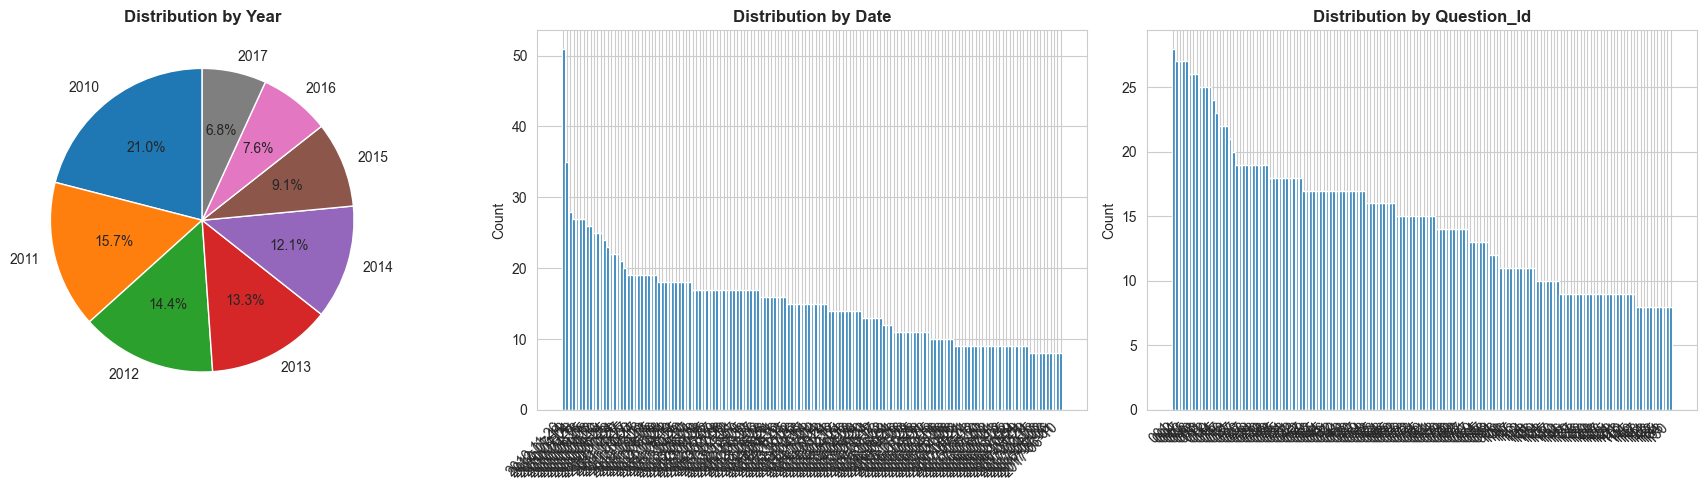


Year distribution:
year
2010    467
2011    349
2012    321
2013    295
2014    270
2015    203
2016    168
2017    152
Name: count, dtype: int64

Date distribution:
date
2010-11-26    51
2012-01-14    35
2010-07-12    28
2010-04-04    27
2010-07-26    27
              ..
2017-08-02     8
2016-02-03     8
2017-07-06     8
2017-06-01     8
2017-06-10     8
Name: count, Length: 147, dtype: int64

Question_Id distribution:
question_id
001    28
002    27
004    27
007    27
003    27
       ..
142     8
135     8
134     8
133     8
150     8
Name: count, Length: 150, dtype: int64

Title distribution:
title
Mother Does a Slow Burn Picking Up Smokers' Trash                    51
Boyfriend Tugs at Heartstrings From a Very Long Distance             35
Aging Parents' Go It Alone Attitude Can Be Dangerous                 28
Reluctant Commuter Feels Torn Between Great Boss, Closer Job         27
Marriage Is About Sharing Love, Not Finding Fault                    27
                           

In [33]:
# Metadata Distribution (if available)

# Check what metadata fields we have
metadata_fields = []
if is_custom_grid:
    # For custom grids, check for year, date, etc.
    for field in ['year', 'date', 'question_id', 'title']:
        if field in df_runs.columns and df_runs[field].notna().any():
            metadata_fields.append(field)
else:
    # For rent scenario, check for perspective, justification, etc.
    for field in ['perspective', 'justification', 'relationship_quality']:
        if field in df_runs.columns and df_runs[field].notna().any():
            metadata_fields.append(field)

if metadata_fields:
    print(f"Available metadata fields: {metadata_fields}")
    
    # Create distribution plots for each field
    n_fields = len(metadata_fields)
    fig, axes = plt.subplots(1, min(3, n_fields), figsize=(6 * min(3, n_fields), 5))
    if n_fields == 1:
        axes = [axes]
    
    for idx, field in enumerate(metadata_fields[:3]):  # Show max 3 fields
        if field in df_success.columns:
            field_data = df_success[field].dropna()
            if len(field_data) > 0:
                field_counts = field_data.value_counts()
                
                if len(field_counts) <= 10:  # Use pie chart for small number of categories
                    axes[idx].pie(field_counts.values, labels=field_counts.index, autopct='%1.1f%%', startangle=90)
                    axes[idx].set_title(f"Distribution by {field.title()}", fontsize=12, fontweight='bold')
                else:  # Use bar chart for many categories
                    axes[idx].bar(range(len(field_counts)), field_counts.values)
                    axes[idx].set_xticks(range(len(field_counts)))
                    axes[idx].set_xticklabels(field_counts.index, rotation=45, ha='right')
                    axes[idx].set_title(f"Distribution by {field.title()}", fontsize=12, fontweight='bold')
                    axes[idx].set_ylabel("Count")
            else:
                axes[idx].text(0.5, 0.5, 'No data', ha='center', va='center')
                axes[idx].set_title(f"Distribution by {field.title()}", fontsize=12, fontweight='bold')
        else:
            axes[idx].text(0.5, 0.5, f'No {field} data', ha='center', va='center')
            axes[idx].set_title(f"Distribution by {field.title()}", fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    for field in metadata_fields:
        if field in df_success.columns:
            field_data = df_success[field].dropna()
            if len(field_data) > 0:
                print(f"\n{field.title()} distribution:")
                print(field_data.value_counts())
else:
    print("No metadata fields available for distribution analysis.")
